In [52]:
# (a) Import all the necessary libraries
import pandas as pd
import numpy as np
import os

In [53]:
def process_freelancer_data():
    # (b) Load the data
    # Ensure the raw file is in the same directory as your script, or provide the full path
    input_file = r"E:\EME Academy classes\Python\Freelancer_files\global_freelancers_raw.csv"
    
    try:
        df = pd.read_csv(input_file)
        print("Data loaded successfully.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {input_file}. Please check the file path.")
        return

In [54]:
# (c) Explore the data
df = pd.read_csv(r"E:\EME Academy classes\Python\Freelancer_files\global_freelancers_raw.csv")
print("First 5 rows of the dataset:")
df.head(6)

First 5 rows of the dataset:


,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%
5,FL250006,Lisa Johnson,female,59.0,Netherlands,Dutch,AI,14.0,$30,2.4,FALSE,NaN


In [55]:
# (e) Checking the data to figure out issues
print("\n--- 1. Exploratory Data Analysis (Data Profiling) ---")
print(f"Dataset Shape (Rows, Columns): {df.shape}\n")

print("Data Types and Non-Null Counts:")
df.info()
        
print("\nMissing Values per Column (Before Cleaning):")
print(df.isnull().sum())


--- 1. Exploratory Data Analysis (Data Profiling) ---
Dataset Shape (Rows, Columns): (1000, 12)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB

Missing Va

In [56]:
# (f) Identifying Data Quality Issues
print("\n--- 2. Data Quality Issues Identified ---")
print("- 'hourly_rate (USD)' contains strings/symbols preventing numeric calculation.")
print("- 'client_satisfaction' is formatted as a string with '%' signs.")
print("- 'gender' and 'is_active' have inconsistent text casing and mixed formats.")
print("- Significant missing values (NaN) exist across age, experience, rates, ratings, and active status.\n")


--- 2. Data Quality Issues Identified ---
- 'hourly_rate (USD)' contains strings/symbols preventing numeric calculation.
- 'client_satisfaction' is formatted as a string with '%' signs.
- 'gender' and 'is_active' have inconsistent text casing and mixed formats.
- Significant missing values (NaN) exist across age, experience, rates, ratings, and active status.



In [57]:
# (g) Cleaning Starts
print("--- 3. Data Cleaning & Transformation ---")

    # Step 1: Structural Cleaning & Formatting
print("Standardizing formats...")

    # Clean 'hourly_rate (USD)': Remove non-numeric characters and convert to float
df['hourly_rate (USD)'] = df['hourly_rate (USD)'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['hourly_rate (USD)'] = pd.to_numeric(df['hourly_rate (USD)'], errors='coerce')

    # Clean 'client_satisfaction': Remove '%' and convert to decimal format
df['client_satisfaction'] = df['client_satisfaction'].astype(str).str.replace('%', '', regex=False)
df['client_satisfaction'] = pd.to_numeric(df['client_satisfaction'], errors='coerce') / 100.0

    # Standardize 'gender': Uppercase and map single letters to full words
df['gender'] = df['gender'].astype(str).str.upper().str.strip()
df['gender'] = df['gender'].replace({'F': 'FEMALE', 'M': 'MALE', 'NAN': np.nan})

    # Standardize 'is_active': Map all variations to boolean True/False
active_mapping = {
        '1': True, '1.0': True, 'Y': True, 'YES': True, 'TRUE': True,
        '0': False, '0.0': False, 'N': False, 'NO': False, 'FALSE': False
    }
df['is_active'] = df['is_active'].astype(str).str.upper().str.strip().map(active_mapping)

    # Step 2: Context-Aware Missing Value Imputation
print("Imputing missing values contextually...")

    # 1. Age & Experience (Interdependent Logic)
    # Impute missing experience using age (assuming a start age of 22), and vice versa
df['years_of_experience'] = df['years_of_experience'].fillna(df['age'] - 22).clip(lower=0)  # Ensure no negative experience
df['age'] = df['age'].fillna(df['years_of_experience'] + 22)

    # Catch any remaining edge cases (if both were missing) with a global median
df['years_of_experience'] = df['years_of_experience'].fillna(df['years_of_experience'].median())
df['age'] = df['age'].fillna(df['age'].median())

    # 2. Hourly Rate (Value-Based Logic)
    # Create temporary experience buckets to group freelancers accurately
df['exp_bucket'] = pd.cut(df['years_of_experience'], bins=[-1, 3, 8, 15, 100], labels=['Junior', 'Mid', 'Senior', 'Expert'])

    # Fill missing rates with the median of their specific skill AND experience level
df['hourly_rate (USD)'] = df.groupby(['primary_skill', 'exp_bucket'], observed=False)['hourly_rate (USD)'].transform(lambda x: x.fillna(x.median()))

    # Fallback for any highly unique outliers using just the primary skill median
df['hourly_rate (USD)'] = df.groupby('primary_skill')['hourly_rate (USD)'].transform(lambda x: x.fillna(x.median()))
    
    # Drop the temporary calculation column
df.drop(columns=['exp_bucket'], inplace=True)

    # 3. Performance KPIs (Skill-Based Logic)
    # Fill ratings and satisfaction based on the median of their specific skill group
df['rating'] = df.groupby('primary_skill')['rating'].transform(lambda x: x.fillna(x.median()))
df['client_satisfaction'] = df.groupby('primary_skill')['client_satisfaction'].transform(lambda x: x.fillna(x.median()))

    # 4. Inactive Defaults
    # Default unknown active status to False to maintain conservative availability metrics
df['is_active'] = df['is_active'].fillna(False)

print("Data cleaning and context-aware imputation complete.")
    
    # Print final validation to show 0 missing values
print("\nMissing Values per Column (After Cleaning):")
print(df.isnull().sum())

--- 3. Data Cleaning & Transformation ---
Standardizing formats...
Imputing missing values contextually...
Data cleaning and context-aware imputation complete.

Missing Values per Column (After Cleaning):
freelancer_ID          0
name                   0
gender                 0
age                    0
country                0
language               0
primary_skill          0
years_of_experience    0
hourly_rate (USD)      0
rating                 0
is_active              0
client_satisfaction    0
dtype: int64


C:\Users\tatha\AppData\Local\Temp\ipykernel_11868\2872660796.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_active'] = df['is_active'].fillna(False)


In [58]:
# (h) Export the Cleaned Data
print("\n--- 4. Data Export ---")
    
    # Define directory and file path
output_dir = r"C:\Users\tatha\Downloads\Python Project Report"
output_file = os.path.join(output_dir, "Freelancers_cleaned.csv")

    # Ensure the directory exists
os.makedirs(output_dir, exist_ok=True)

    # Save to CSV without the index column
df.to_csv(output_file, index=False)
print(f"Success! Cleaned dataset saved to:\n{output_file}")

# Execute the pipeline
if __name__ == "__main__":
    process_freelancer_data()


--- 4. Data Export ---
Success! Cleaned dataset saved to:
C:\Users\tatha\Downloads\Python Project Report\Freelancers_cleaned.csv
Data loaded successfully.



In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# ==========================
# Load the cleaned dataset
# ==========================
df = pd.read_csv(r"C:\Users\tatha\Downloads\Python Project Report\Freelancers_cleaned.csv")

# ==========================
# SQL Server Connection
# ==========================
server = r"TATHAGATA\SQLEXPRESS"
database = "PRACTICEDB"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# ==========================
# Push Data to SQL Server
# ==========================
df.to_sql(
    name="FREELANCERS",
    con=engine,
    if_exists="replace",   # Options: replace, append, fail
    index=False
)
print("Data successfully imported into PRACTICEDB.dbo.FREELANCERS")

c:\Users\tatha\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Data successfully imported into PRACTICEDB.dbo.FREELANCERS


II. Exploratory Data Analysis (EDA)

In [60]:
# =========================
# Column Type Separation
# =========================
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("\nNumeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numeric Columns: ['age', 'years_of_experience', 'hourly_rate (USD)', 'rating', 'client_satisfaction']
Categorical Columns: ['freelancer_ID', 'name', 'gender', 'country', 'language', 'primary_skill', 'is_active']


In [61]:
df.describe()

,age,years_of_experience,hourly_rate (USD),rating,client_satisfaction
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,40.183000,11.61800,51.602500,2.522200,0.792970
std,11.943624,9.82235,26.276009,1.467638,0.104547
min,20.000000,0.00000,20.000000,0.000000,0.600000
25%,31.000000,3.00000,30.000000,1.500000,0.710000
50%,40.000000,10.00000,40.000000,2.600000,0.790000
75%,51.000000,18.00000,75.000000,3.700000,0.870000
max,60.000000,41.00000,100.000000,5.000000,1.000000


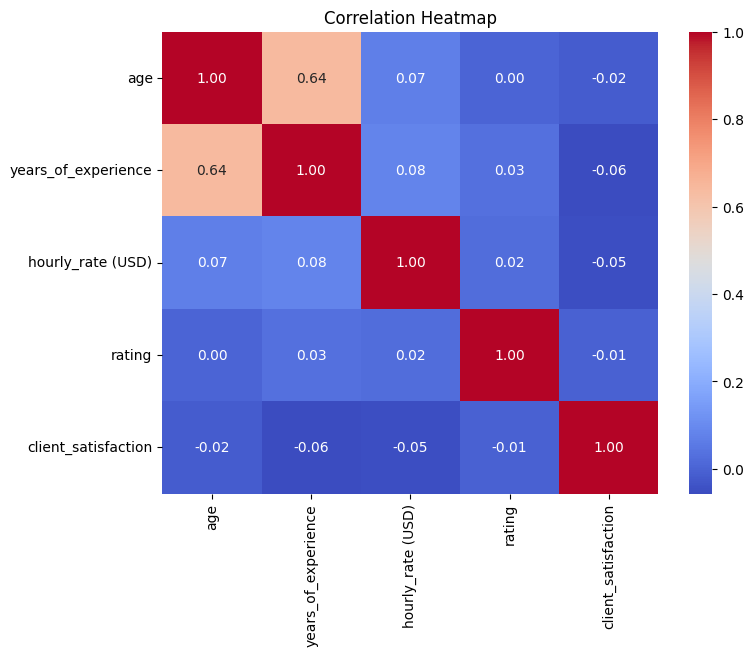

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "age",
    "years_of_experience",
    "hourly_rate (USD)",
    "rating",
    "client_satisfaction"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

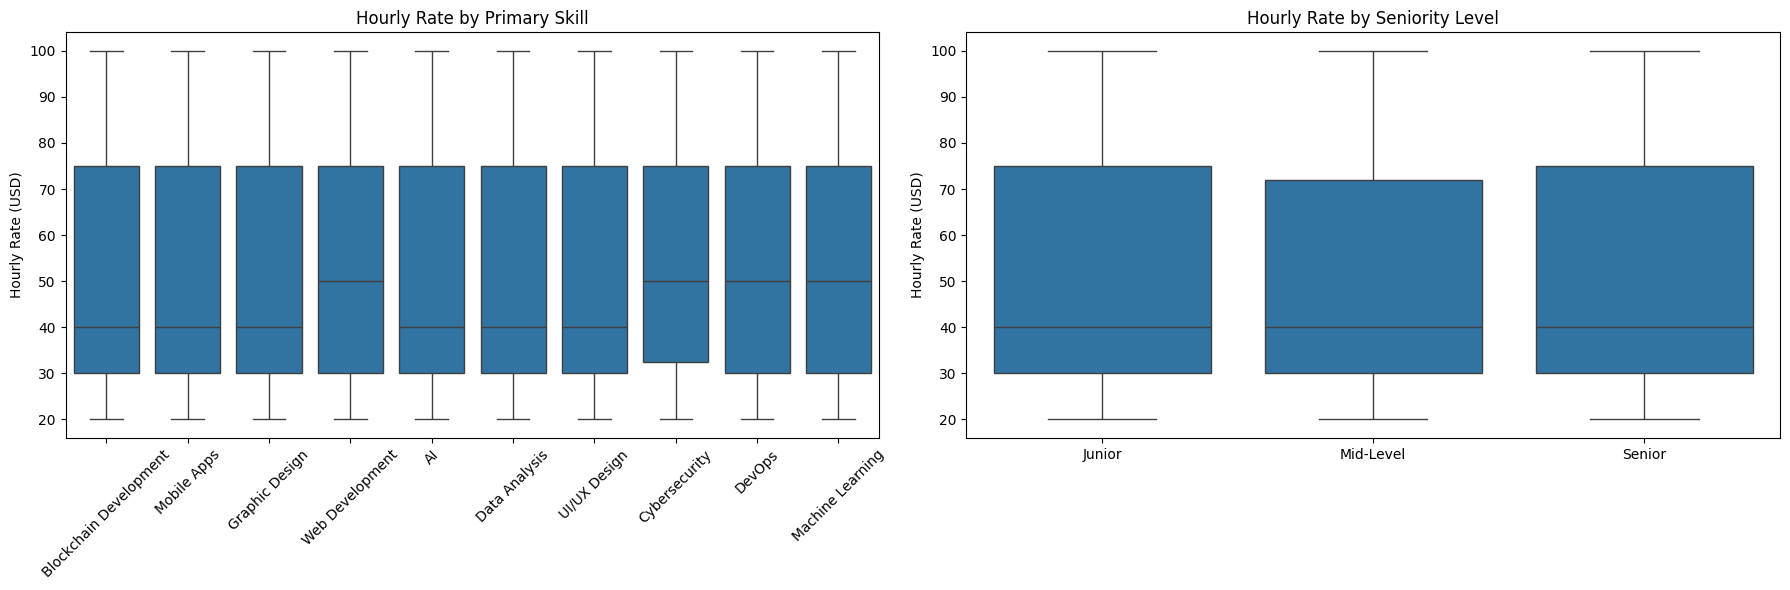

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Experience Tier"] = pd.cut(
    df["years_of_experience"],
    bins=[-1, 3, 9, 100],
    labels=["Junior", "Mid-Level", "Senior"]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Boxplot 1: Hourly Rate by Primary Skill
sns.boxplot(
    data=df,
    x="primary_skill",
    y="hourly_rate (USD)",
    ax=axes[0]
)
axes[0].set_title("Hourly Rate by Primary Skill")
axes[0].set_xlabel("")
axes[0].set_ylabel("Hourly Rate (USD)")
axes[0].tick_params(axis='x', rotation=45)

# Boxplot 2: Hourly Rate by Experience Tier
sns.boxplot(
    data=df,
    x="Experience Tier",
    y="hourly_rate (USD)",
    ax=axes[1]
)
axes[1].set_title("Hourly Rate by Seniority Level")
axes[1].set_xlabel("")
axes[1].set_ylabel("Hourly Rate (USD)")
plt.tight_layout()
plt.show()

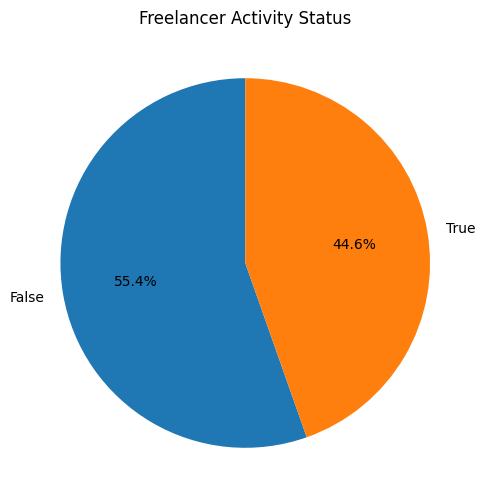

In [64]:
status = df["is_active"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status,
    labels=status.index.astype(str),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Freelancer Activity Status")
plt.show()

C:\Users\tatha\AppData\Local\Temp\ipykernel_11868\494985082.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


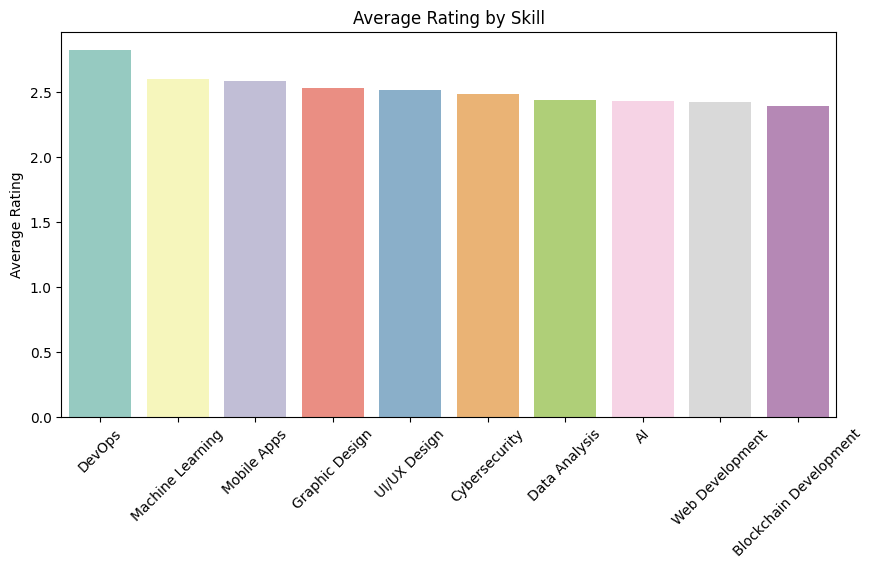

In [65]:
plt.figure(figsize=(10,5))

rating_skill = (
    df.groupby("primary_skill")["rating"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=rating_skill.index,
    y=rating_skill.values,
    palette="Set3"
)

plt.xticks(rotation=45)
plt.title("Average Rating by Skill")
plt.xlabel("")
plt.ylabel("Average Rating")
plt.show()

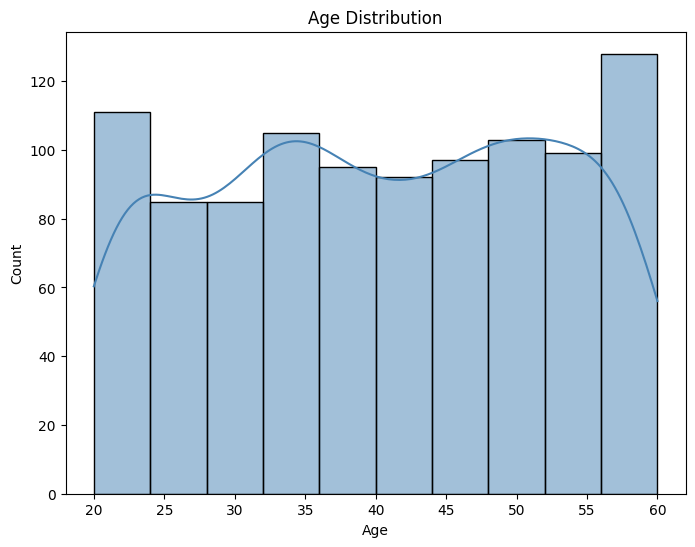

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    data=df,
    x="age",
    bins=10,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

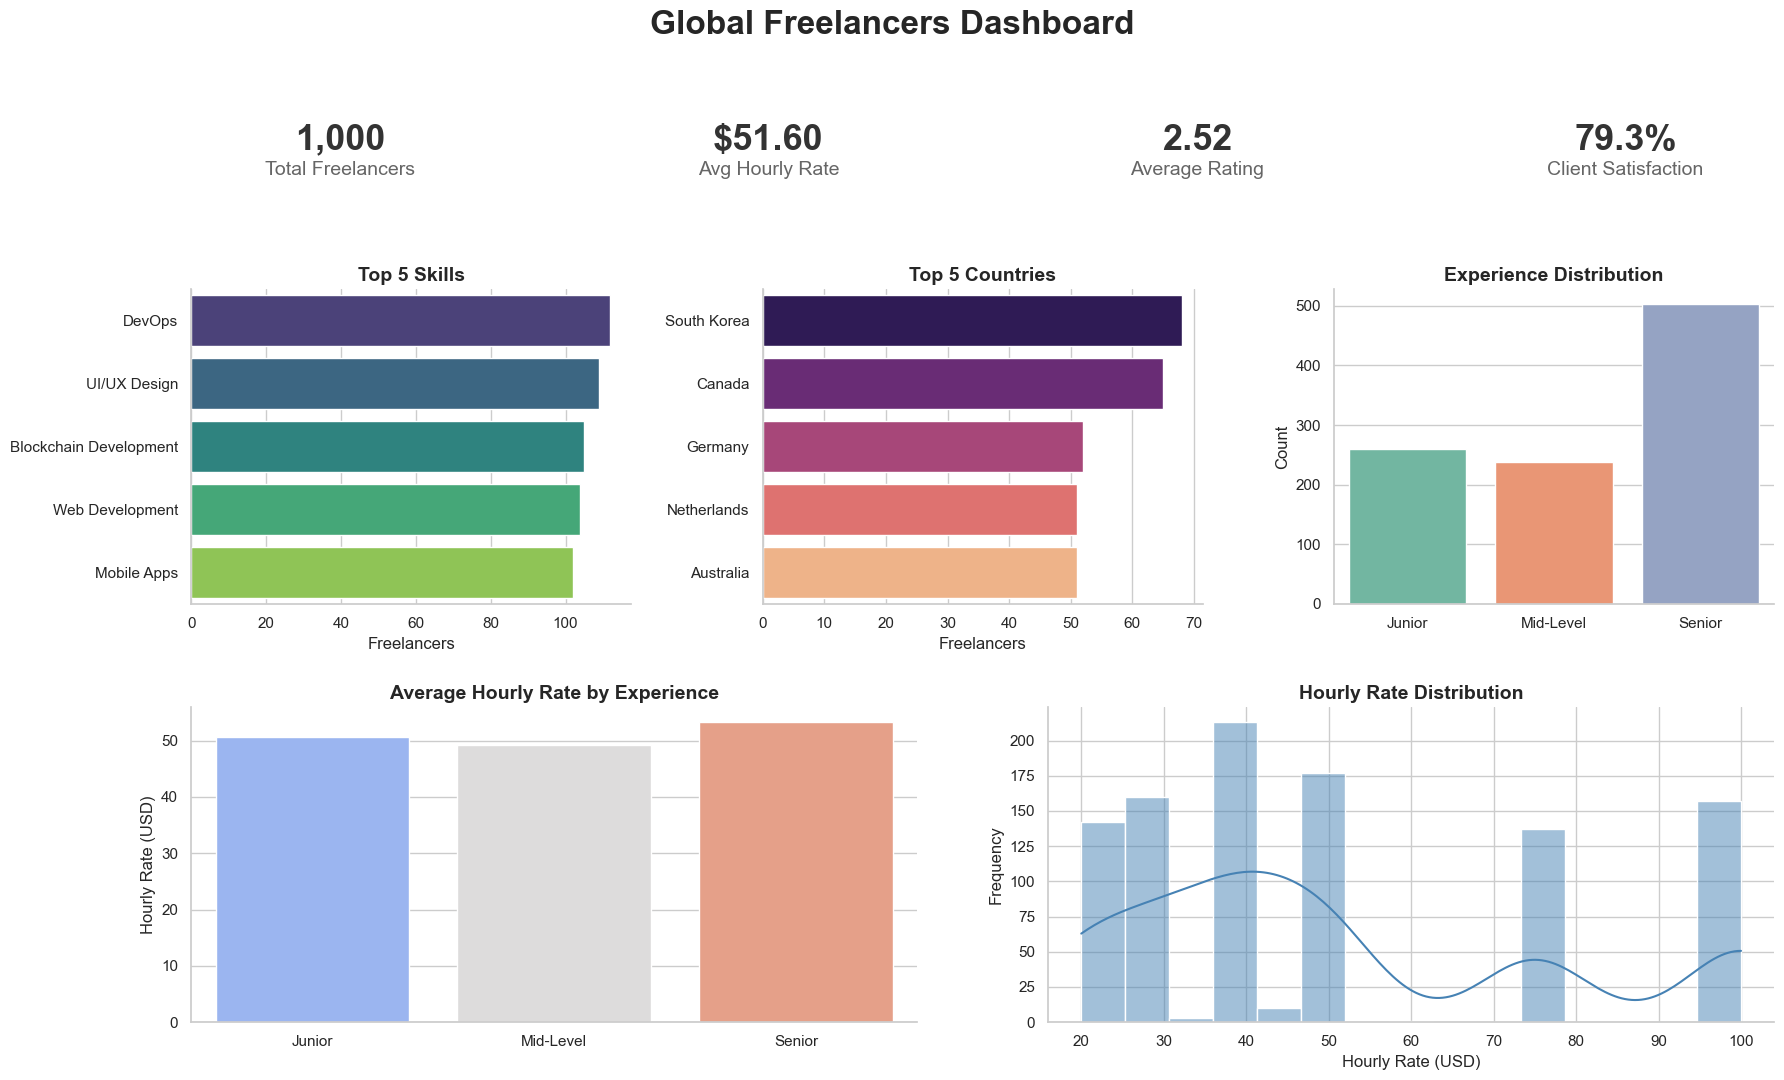

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean report output
warnings.filterwarnings('ignore')

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv(r"C:\Users\tatha\Downloads\Python Project Report\Freelancers_cleaned.csv")

sns.set_theme(style="whitegrid")

# ----------------------------
# Experience Tier
# ----------------------------
df["Experience Tier"] = pd.cut(
    df["years_of_experience"],
    bins=[-1, 3, 9, 100],
    labels=["Junior", "Mid-Level", "Senior"]
)

# ----------------------------
# KPI Values
# ----------------------------
total = len(df)
avg_rate = df["hourly_rate (USD)"].mean()
avg_rating = df["rating"].mean()
avg_sat = df["client_satisfaction"].mean() * 100

# ==========================================================
# Figure & Layout
# ==========================================================
# Slightly taller figure to give the charts room to breathe
fig = plt.figure(figsize=(18, 11), facecolor="white")

# Adjusted height ratios so KPIs don't take up too much vertical space
gs = fig.add_gridspec(
    nrows=3,
    ncols=12,
    height_ratios=[0.6, 2.5, 2.5] 
)

fig.suptitle(
    "Global Freelancers Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# ==========================================================
# KPI CARDS
# ==========================================================
titles = ["Total Freelancers","Avg Hourly Rate","Average Rating","Client Satisfaction"]

values = [
    f"{total:,}",
    f"${avg_rate:.2f}",
    f"{avg_rating:.2f}",
    f"{avg_sat:.1f}%"
]

for i in range(4):
    ax = fig.add_subplot(gs[0, i*3:(i+1)*3])
    ax.axis("off")
    
    # Force the invisible axis limits so text is perfectly centered
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.5, 0.60, values[i], 
        fontsize=26, fontweight="bold", color="#333333",
        ha="center", va="center"
    )

    ax.text(
        0.5, 0.20, titles[i], 
        fontsize=14, color="#666666",
        ha="center", va="center"
    )

# ==========================================================
# Top Skills
# ==========================================================
ax1 = fig.add_subplot(gs[1,0:4])
skills = df["primary_skill"].value_counts().head(5)

sns.barplot(
    x=skills.values, y=skills.index, 
    hue=skills.index, palette="viridis", legend=False, ax=ax1
)

ax1.set_title("Top 5 Skills", fontsize=14, fontweight='bold')
ax1.set_xlabel("Freelancers")
ax1.set_ylabel("")
sns.despine(ax=ax1)

# ==========================================================
# Top Countries
# ==========================================================
ax2 = fig.add_subplot(gs[1,4:8])
countries = df["country"].value_counts().head(5)

sns.barplot(
    x=countries.values, y=countries.index, 
    hue=countries.index, palette="magma", legend=False, ax=ax2
)

ax2.set_title("Top 5 Countries", fontsize=14, fontweight='bold')
ax2.set_xlabel("Freelancers")
ax2.set_ylabel("")
sns.despine(ax=ax2)

# ==========================================================
# Experience Distribution
# ==========================================================
ax3 = fig.add_subplot(gs[1,8:12])

sns.countplot(
    data=df, x="Experience Tier", 
    hue="Experience Tier", palette="Set2", legend=False, ax=ax3
)

ax3.set_title("Experience Distribution", fontsize=14, fontweight='bold')
ax3.set_xlabel("")
ax3.set_ylabel("Count")
sns.despine(ax=ax3)

# ==========================================================
# Average Hourly Rate
# ==========================================================
ax4 = fig.add_subplot(gs[2,0:6])

sns.barplot(
    data=df, x="Experience Tier", y="hourly_rate (USD)", 
    hue="Experience Tier", palette="coolwarm", errorbar=None, legend=False, ax=ax4
)

ax4.set_title("Average Hourly Rate by Experience", fontsize=14, fontweight='bold')
ax4.set_xlabel("")
ax4.set_ylabel("Hourly Rate (USD)")
sns.despine(ax=ax4)

# ==========================================================
# Hourly Rate Distribution
# ==========================================================
ax5 = fig.add_subplot(gs[2,6:12])

sns.histplot(
    data=df, x="hourly_rate (USD)", 
    bins=15, kde=True, color="steelblue", ax=ax5
)

ax5.set_title("Hourly Rate Distribution", fontsize=14, fontweight='bold')
ax5.set_xlabel("Hourly Rate (USD)")
ax5.set_ylabel("Frequency")
sns.despine(ax=ax5)

# ==========================================================
# Final Spacing
# ==========================================================
# This automatically calculates padding without causing overlap.
# rect=[left, bottom, right, top] ensures it doesn't overlap the suptitle.
fig.tight_layout(rect=[0, 0, 1, 0.95], w_pad=2.0, h_pad=2.0)

plt.show()